In [1]:
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# ============================================================
# 1. Reproducibility and device configuration
# ============================================================
def seed_everything(seed=42):
    """
    Set random seeds for reproducible model training.
    """
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        torch.use_deterministic_algorithms(True)
    except Exception as error:
        print(
            "Warning: deterministic algorithms "
            f"were not fully enabled: {error}"
        )


seed_everything(42)

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)

Using device: cpu


In [3]:
# ============================================================
# 2. Define the multilayer perceptron model
# ============================================================
class MLPRegressor(nn.Module):
    """
    Multilayer perceptron for overpotential regression.
    """

    def __init__(
        self,
        input_dim,
        hidden_dims=None,
        dropout=0.1
    ):
        super().__init__()

        if hidden_dims is None:
            hidden_dims = [256, 128, 64]

        feature_layers = []
        dimensions = [input_dim] + hidden_dims

        for i in range(len(hidden_dims)):
            feature_layers.append(
                nn.Linear(
                    dimensions[i],
                    dimensions[i + 1]
                )
            )

            feature_layers.append(
                nn.BatchNorm1d(
                    dimensions[i + 1]
                )
            )

            feature_layers.append(
                nn.ReLU()
            )

            feature_layers.append(
                nn.Dropout(dropout)
            )

        self.feature_extractor = nn.Sequential(
            *feature_layers
        )

        self.regressor = nn.Linear(
            hidden_dims[-1],
            1
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.regressor(x)

        return x

In [4]:
# ============================================================
# 3. Load the five-metal target-domain dataset
# ============================================================
target_data_path = "data/5metal_data_features.csv"

df_5m = pd.read_csv(target_data_path)

y_5m = df_5m["overpotential"].values

X_5m_df = df_5m.drop(
    columns=[
        "compound",
        "overpotential",
        "composition_key"
    ]
)

X_5m = X_5m_df.values

print(
    "Complete five-metal dataset:",
    X_5m.shape
)


# ============================================================
# 4. Split the five-metal dataset
# ============================================================

# Divide overpotential values into five quantile-based bins
# for stratified splitting of the regression dataset
y_bins = pd.qcut(
    y_5m,
    q=5,
    labels=False,
    duplicates="drop"
)

# Use 30% of the five-metal samples for combined training
# and retain 70% as an independent five-metal test set
(
    X_5m_train_raw,
    X_5m_test_raw,
    y_5m_train,
    y_5m_test
) = train_test_split(
    X_5m,
    y_5m,
    test_size=0.7,
    random_state=2027,
    stratify=y_bins
)

print(
    "Five-metal training subset:",
    X_5m_train_raw.shape,
    y_5m_train.shape
)

print(
    "Five-metal test set:",
    X_5m_test_raw.shape,
    y_5m_test.shape
)


Complete five-metal dataset: (246, 25)
Five-metal training subset: (73, 25) (73,)
Five-metal test set: (173, 25) (173,)


In [5]:
# ============================================================
# 5. Load the source-domain dataset
# ============================================================
source_data_path = "data/alldata_features.csv"

df_source = pd.read_csv(source_data_path)

y_source = df_source["overpotential"].values

X_source_df = df_source.drop(
    columns=[
        "compound",
        "overpotential",
        "composition_key"
    ]
)

X_source = X_source_df.values

print(
    "Source-domain dataset:",
    X_source.shape,
    y_source.shape
)

Source-domain dataset: (846, 25) (846,)


In [7]:
# ============================================================
# 6. Verify feature consistency between the two domains
# ============================================================
if list(X_source_df.columns) != list(X_5m_df.columns):
    raise ValueError(
        "The source-domain and target-domain datasets "
        "do not contain the same ordered input features."
    )

print(
    "Number of shared input features:",
    X_source.shape[1]
)

# ============================================================
# 7. Construct the combined Scheme C training dataset
# ============================================================

# Directly combine all source-domain samples with the
# five-metal training subset
X_train_raw_C = np.vstack(
    [
        X_source,
        X_5m_train_raw
    ]
)

y_train_C = np.concatenate(
    [
        y_source,
        y_5m_train
    ]
)

# Evaluate only on the independent five-metal test set
X_test_raw_C = X_5m_test_raw
y_test_C = y_5m_test

print(
    "Scheme C combined training set:",
    X_train_raw_C.shape,
    y_train_C.shape
)

print(
    "Scheme C five-metal test set:",
    X_test_raw_C.shape,
    y_test_C.shape
)


Number of shared input features: 25
Scheme C combined training set: (919, 25) (919,)
Scheme C five-metal test set: (173, 25) (173,)


In [8]:
# ============================================================
# 8. Standardize the input features
# ============================================================
scaler_C = StandardScaler()

# Fit the scaler using only the combined training dataset
X_train_C = scaler_C.fit_transform(
    X_train_raw_C
)

# Apply the fitted scaler to the independent test set
X_test_C = scaler_C.transform(
    X_test_raw_C
)

print(
    "Scheme C scaled training set:",
    X_train_C.shape
)

print(
    "Scheme C scaled test set:",
    X_test_C.shape
)


Scheme C scaled training set: (919, 25)
Scheme C scaled test set: (173, 25)


In [9]:
# ============================================================
# 9. Create data loaders
# ============================================================
train_loader_C = DataLoader(
    TensorDataset(
        torch.tensor(
            X_train_C,
            dtype=torch.float32
        ),
        torch.tensor(
            y_train_C,
            dtype=torch.float32
        ).view(-1, 1)
    ),
    batch_size=32,
    shuffle=True
)

train_eval_loader_C = DataLoader(
    TensorDataset(
        torch.tensor(
            X_train_C,
            dtype=torch.float32
        ),
        torch.tensor(
            y_train_C,
            dtype=torch.float32
        ).view(-1, 1)
    ),
    batch_size=32,
    shuffle=False
)

test_loader_C = DataLoader(
    TensorDataset(
        torch.tensor(
            X_test_C,
            dtype=torch.float32
        ),
        torch.tensor(
            y_test_C,
            dtype=torch.float32
        ).view(-1, 1)
    ),
    batch_size=32,
    shuffle=False
)

In [10]:
# ============================================================
# 10. Define the training function
# ============================================================
def train_model_fixed_epochs(
    model,
    train_loader,
    epochs=350,
    lr=5e-5,
    weight_decay=1e-3,
    device=None
):
    """
    Train a model for a fixed number of epochs.
    """
    if device is None:
        device = torch.device(
            "cuda"
            if torch.cuda.is_available()
            else "cpu"
        )

    model = model.to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    criterion = nn.MSELoss()
    train_losses = []

    for epoch in range(epochs):
        model.train()

        total_train_loss = 0.0
        n_train = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            predictions = model(X_batch)

            loss = criterion(
                predictions,
                y_batch
            )

            loss.backward()
            optimizer.step()

            batch_size = X_batch.size(0)

            total_train_loss += (
                loss.item() * batch_size
            )

            n_train += batch_size

        epoch_train_loss = (
            total_train_loss / n_train
        )

        train_losses.append(
            epoch_train_loss
        )

        if (
            epoch % 20 == 0
            or epoch == epochs - 1
        ):
            print(
                f"Epoch {epoch:03d}: "
                f"Train Loss={epoch_train_loss:.6f}"
            )

    return model, train_losses


In [11]:
# ============================================================
# 11. Train Scheme C on the directly combined dataset
# ============================================================
seed_everything(42)

model_C = MLPRegressor(
    input_dim=X_train_C.shape[1],
    hidden_dims=[256, 128, 64],
    dropout=0.02
)

model_C, train_losses_C = train_model_fixed_epochs(
    model=model_C,
    train_loader=train_loader_C,
    epochs=250,
    lr=2e-5,
    weight_decay=1.5e-2,
    device=device
)


Epoch 000: Train Loss=1.807994
Epoch 020: Train Loss=0.730624
Epoch 040: Train Loss=0.322016
Epoch 060: Train Loss=0.153309
Epoch 080: Train Loss=0.077620
Epoch 100: Train Loss=0.056527
Epoch 120: Train Loss=0.051853
Epoch 140: Train Loss=0.043807
Epoch 160: Train Loss=0.037038
Epoch 180: Train Loss=0.034670
Epoch 200: Train Loss=0.032913
Epoch 220: Train Loss=0.032599
Epoch 240: Train Loss=0.030076
Epoch 249: Train Loss=0.028608


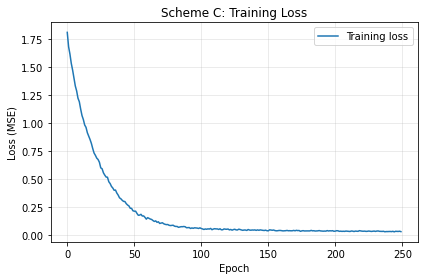

In [12]:
# ============================================================
# 12. Plot the training loss
# ============================================================
plt.figure(figsize=(6, 4))

plt.plot(
    train_losses_C,
    label="Training loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Scheme C: Training Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [13]:
# ============================================================
# 13. Define prediction and evaluation functions
# ============================================================
def mean_absolute_percentage_error(
    y_true,
    y_pred
):
    """
    Calculate the mean absolute percentage error.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    nonzero_mask = y_true != 0

    if nonzero_mask.sum() == 0:
        return np.nan

    return (
        np.mean(
            np.abs(
                (
                    y_true[nonzero_mask]
                    - y_pred[nonzero_mask]
                )
                / y_true[nonzero_mask]
            )
        )
        * 100
    )


def compute_metrics(y_true, y_pred):
    """
    Calculate regression performance metrics.
    """
    mse = mean_squared_error(
        y_true,
        y_pred
    )

    return {
        "MAE": mean_absolute_error(
            y_true,
            y_pred
        ),
        "RMSE": np.sqrt(mse),
        "MSE": mse,
        "R2": r2_score(
            y_true,
            y_pred
        ),
        "MAPE": mean_absolute_percentage_error(
            y_true,
            y_pred
        )
    }


def predict(loader, model, device):
    """
    Generate model predictions for a data loader.
    """
    model.eval()

    predictions = []
    true_values = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            batch_predictions = (
                model(X_batch)
                .cpu()
                .numpy()
                .flatten()
            )

            batch_true_values = (
                y_batch
                .cpu()
                .numpy()
                .flatten()
            )

            predictions.extend(
                batch_predictions
            )

            true_values.extend(
                batch_true_values
            )

    return (
        np.asarray(true_values),
        np.asarray(predictions)
    )


In [14]:
# ============================================================
# 14. Evaluate Scheme C
# ============================================================
(
    y_train_true_C,
    y_train_pred_C
) = predict(
    train_eval_loader_C,
    model_C,
    device
)

(
    y_test_true_C,
    y_test_pred_C
) = predict(
    test_loader_C,
    model_C,
    device
)

train_metrics_C = compute_metrics(
    y_train_true_C,
    y_train_pred_C
)

test_metrics_C = compute_metrics(
    y_test_true_C,
    y_test_pred_C
)

print(
    "=== Scheme C: Combined Training Metrics ==="
)

for metric_name, metric_value in train_metrics_C.items():
    print(
        f"{metric_name}: {metric_value:.6f}"
    )

print(
    "\n=== Scheme C: Five-Metal Test Metrics ==="
)

for metric_name, metric_value in test_metrics_C.items():
    print(
        f"{metric_name}: {metric_value:.6f}"
    )


=== Scheme C: Combined Training Metrics ===
MAE: 0.078231
RMSE: 0.106121
MSE: 0.011262
R2: 0.924429
MAPE: 6.842376

=== Scheme C: Five-Metal Test Metrics ===
MAE: 0.128102
RMSE: 0.162292
MSE: 0.026339
R2: 0.733868
MAPE: 10.911746


In [15]:
# ============================================================
# 15. Save Scheme C predictions
# ============================================================
os.makedirs(
    "results",
    exist_ok=True
)

schemeC_train_df = pd.DataFrame(
    {
        "Actual_Overpotential": np.ravel(
            y_train_true_C
        ),
        "Predicted_Overpotential": np.ravel(
            y_train_pred_C
        ),
        "Absolute_Error": np.abs(
            np.ravel(y_train_true_C)
            - np.ravel(y_train_pred_C)
        )
    }
)

schemeC_test_df = pd.DataFrame(
    {
        "Actual_Overpotential": np.ravel(
            y_test_true_C
        ),
        "Predicted_Overpotential": np.ravel(
            y_test_pred_C
        ),
        "Absolute_Error": np.abs(
            np.ravel(y_test_true_C)
            - np.ravel(y_test_pred_C)
        )
    }
)

schemeC_train_path = (
    "results/schemeC_combined_train_predictions.csv"
)

schemeC_test_path = (
    "results/schemeC_test_predictions.csv"
)

schemeC_train_df.to_csv(
    schemeC_train_path,
    index=False
)

schemeC_test_df.to_csv(
    schemeC_test_path,
    index=False
)

print(
    "Scheme C combined-training predictions saved to:",
    schemeC_train_path
)

print(
    "Scheme C five-metal test predictions saved to:",
    schemeC_test_path
)


Scheme C combined-training predictions saved to: results/schemeC_combined_train_predictions.csv
Scheme C five-metal test predictions saved to: results/schemeC_test_predictions.csv


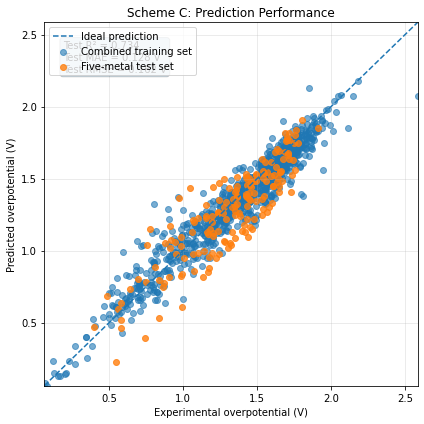

In [16]:
# ============================================================
# 16. Plot actual versus predicted overpotentials
# ============================================================
plt.figure(figsize=(6, 6))

plt.scatter(
    y_train_true_C,
    y_train_pred_C,
    alpha=0.6,
    label="Combined training set"
)

plt.scatter(
    y_test_true_C,
    y_test_pred_C,
    alpha=0.8,
    label="Five-metal test set"
)

all_true_values = np.concatenate(
    [
        np.ravel(y_train_true_C),
        np.ravel(y_test_true_C)
    ]
)

all_predicted_values = np.concatenate(
    [
        np.ravel(y_train_pred_C),
        np.ravel(y_test_pred_C)
    ]
)

minimum_value = min(
    all_true_values.min(),
    all_predicted_values.min()
)

maximum_value = max(
    all_true_values.max(),
    all_predicted_values.max()
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    linewidth=1.5,
    label="Ideal prediction"
)

plt.xlabel("Experimental overpotential (V)")
plt.ylabel("Predicted overpotential (V)")
plt.title("Scheme C: Prediction Performance")

plt.xlim(
    minimum_value,
    maximum_value
)

plt.ylim(
    minimum_value,
    maximum_value
)

metric_text = (
    f"Test R² = {test_metrics_C['R2']:.3f}\n"
    f"Test MAE = {test_metrics_C['MAE']:.3f} V\n"
    f"Test RMSE = {test_metrics_C['RMSE']:.3f} V"
)

plt.text(
    0.05,
    0.95,
    metric_text,
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox={
        "boxstyle": "round",
        "alpha": 0.2
    }
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()